# 13. Survival analysis: time to an observable successor

This notebook answers the internship's operational question: **given a digital
public contract that has run for a while without being re-procured, how likely
is a new purchasing need to become visible in the next 12 to 24 months?**

The unit is one contract (a cohort episode). Time zero is the award-notice
date.

* **Event** — an observable successor procurement was accepted by the frozen
  linkage policy. Time to event runs to the successor's *first notice*, because
  a renewed need becomes visible when the new tender is published.
* **Censored** — no successor was accepted before the 2025-12-31 cutoff.

A censored contract is **not** a contract proven never to be renewed. It is one
for which no successor was identified in BOAMP before the cutoff. Keeping those
rows as censored rather than deleting them, or counting them as negatives, is
the entire reason survival analysis is the right framework here.

## 1. Reproducible setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "boamp_pipeline").is_dir():
            return candidate
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed" / "boamp"
FIGURES = PROCESSED / "figures" / "survival_analysis"
FIGURES.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-4 of the reference palette, used in fixed order so a
# segment keeps its colour across every figure in the report.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "legend.frameon": False,
})


def save(fig, name):
    path = FIGURES / name
    fig.savefig(path)
    print(f"saved {path.relative_to(PROJECT_ROOT)}")


def load_json(name):
    return json.loads((PROCESSED / name).read_text(encoding="utf-8"))


In [2]:
from lifelines import CoxPHFitter, KaplanMeierFitter, WeibullFitter
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test

survival = pd.read_parquet(PROCESSED / "survival_dataset.parquet")
summary = load_json("survival_dataset_summary.json")
linkage = load_json("linkage_config.json")

MONTHS = 30.4375
# Three contracts were awarded on the cutoff date itself and so carry zero
# follow-up. They are censored and contribute no information either way; a
# one-day floor keeps them representable without changing any estimate.
survival["t_months"] = np.maximum(survival["duration_days"], 1) / MONTHS

print(f"contracts        : {len(survival):,}")
print(f"events           : {int(survival['event'].sum()):,}")
print(f"censored         : {int((survival['event'] == 0).sum()):,}")
print(f"event rate       : {survival['event'].mean():.3f}")
print(f"linkage policy   : {linkage['selected_method']} @ {linkage['selected_threshold']}")
print(f"validation passed: {summary['validation_passed']}")

contracts        : 3,800
events           : 544
censored         : 3,256
event rate       : 0.143
linkage policy   : M_B_text_ranking @ 70.0
validation passed: True


## 2. Structural validation before any model

None of these checks may fail. A negative duration, a duplicated contract, or
an anchor linked to itself would each silently corrupt the hazard estimates.

In [3]:
checks = summary["variants"]["main"]["validation"]
display(pd.DataFrame({"value": checks}).T)
assert checks["events_plus_censored_equals_rows"]
assert checks["negative_durations"] == 0
assert checks["duplicate_episodes"] == 0
assert checks["successor_equals_anchor"] == 0
print("all structural checks passed")

,rows,unique_episodes,events,censored,events_plus_censored_equals_rows,negative_durations,zero_durations,duplicate_episodes,successor_equals_anchor
value,3800,3800,544,3256,True,0,3,0,0


all structural checks passed


## 3. Overall Kaplan-Meier

The Kaplan-Meier estimator gives the probability that a contract is still
*without an observable successor* at each point after its award, using every
contract's follow-up time including the censored ones.

saved data/processed/boamp/figures/survival_analysis/01_kaplan_meier_overall.png


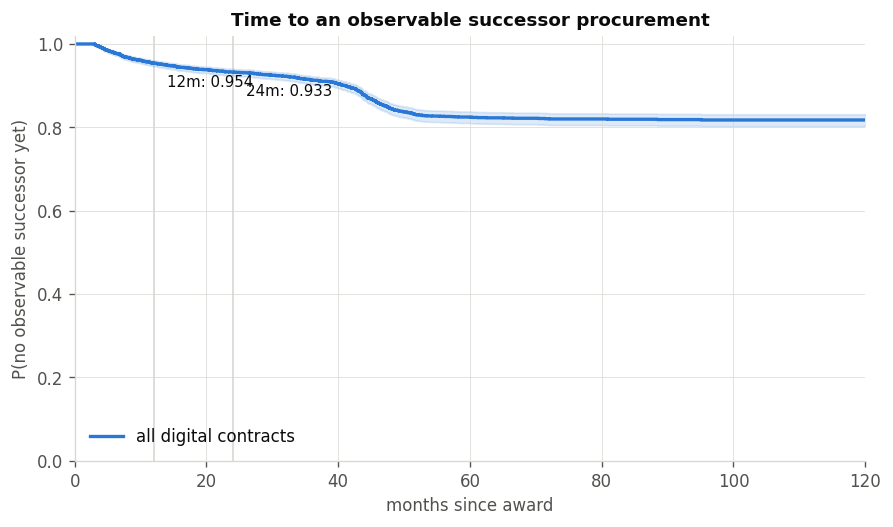

,survival,P(successor by then)
months,,
0,1.000,0.000
12,0.954,0.046
24,0.933,0.067
36,0.913,0.087
48,0.845,0.155
60,0.825,0.175


median time to observable successor: inf months


In [4]:
kmf = KaplanMeierFitter()
kmf.fit(survival["t_months"], survival["event"], label="all digital contracts")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
kmf.plot_survival_function(ax=ax, color=PALETTE[0], linewidth=2, ci_alpha=0.15)
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 120)
ax.set_title("Time to an observable successor procurement")
for horizon in (12, 24):
    value = float(kmf.survival_function_at_times(horizon).iloc[0])
    ax.axvline(horizon, color=GRID, linewidth=1, zorder=0)
    ax.annotate(f"{horizon}m: {value:.3f}", (horizon, value),
                textcoords="offset points", xytext=(8, -14), fontsize=9, color=INK)
ax.legend(loc="lower left")
save(fig, "01_kaplan_meier_overall.png")
plt.show()

at_risk = pd.DataFrame({
    "months": [0, 12, 24, 36, 48, 60],
    "survival": [float(kmf.survival_function_at_times(t).iloc[0]) for t in [0, 12, 24, 36, 48, 60]],
})
at_risk["P(successor by then)"] = (1 - at_risk["survival"]).round(3)
at_risk["survival"] = at_risk["survival"].round(3)
display(at_risk.set_index("months"))
print(f"median time to observable successor: {kmf.median_survival_time_} months")

Because only about 14% of contracts receive an accepted link, the curve stays high
and the median survival time is not reached inside the observation window. That
is the expected consequence of a precision-first linkage policy and it is why
the absolute level of this curve should not be read as "the renewal rate". What
the curve supports is *relative* comparison and conditional short-horizon
probabilities, which is what the operational question actually asks for.

## 4. By technological segment

Segment curves are only shown where the segment carries enough events to
support one. The guideline's rule of thumb is at least 30 observed events per
stratum; all four digital segments clear it comfortably.

,contracts,events
digital_segment,,
CPV-32,1152,152
CPV-35,564,115
CPV-48,790,92
CPV-72,1294,185


saved data/processed/boamp/figures/survival_analysis/02_kaplan_meier_by_segment.png


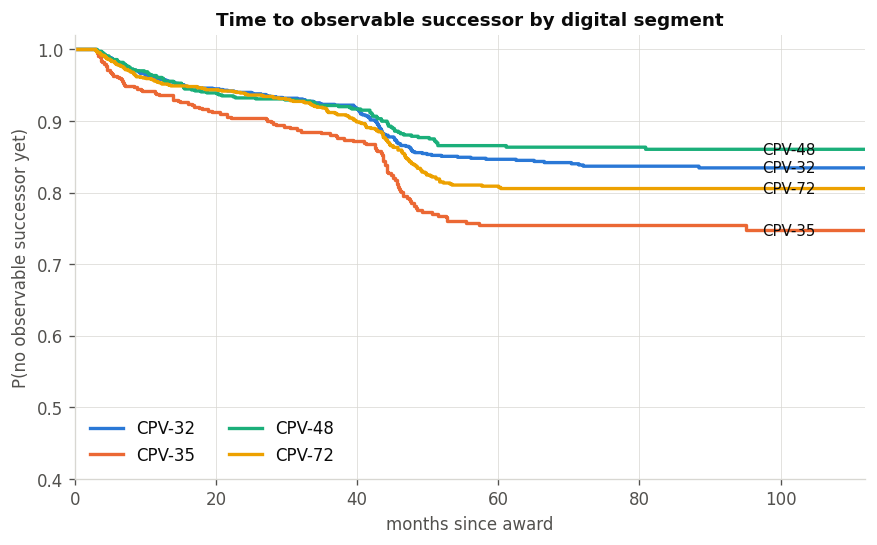

log-rank across segments: statistic=23.45, p=3.257e-05


In [5]:
segments = sorted(survival["digital_segment"].unique())
counts = (survival.groupby("digital_segment")["event"]
          .agg(contracts="size", events="sum"))
display(counts)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for i, segment in enumerate(segments):
    mask = survival["digital_segment"] == segment
    fitter = KaplanMeierFitter()
    fitter.fit(survival.loc[mask, "t_months"], survival.loc[mask, "event"], label=segment)
    fitter.plot_survival_function(ax=ax, color=PALETTE[i], linewidth=2, ci_show=False)
    end = float(fitter.survival_function_at_times(96).iloc[0])
    ax.annotate(segment, (96, end), textcoords="offset points", xytext=(6, 0),
                color=INK, fontsize=9, va="center")
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_ylim(0.4, 1.02)
ax.set_xlim(0, 112)
ax.set_title("Time to observable successor by digital segment")
ax.legend(loc="lower left", ncols=2)
save(fig, "02_kaplan_meier_by_segment.png")
plt.show()

logrank = multivariate_logrank_test(survival["t_months"], survival["digital_segment"],
                                    survival["event"])
print(f"log-rank across segments: statistic={logrank.test_statistic:.2f}, "
      f"p={logrank.p_value:.4g}")

## 5. Cox proportional hazards

The Cox model estimates how covariates shift the hazard of an observable
successor appearing, without assuming a shape for the baseline hazard.

The model is kept deliberately small. With 544 events the one-covariate-per-ten-events
rule permits far more, but a small model is easier to defend and each variable
here has a clear interpretation. `duration_months` is **excluded** despite being
theoretically relevant: it is missing for roughly 75% of the cohort, and
including it would either discard three quarters of the data or require the
imputation this project has refused throughout.

In [6]:
design = survival[["t_months", "event", "digital_segment", "buyer_region",
                   "framework_flag", "buyer_identifier_quality", "award_year"]].copy()
design["framework_flag"] = design["framework_flag"].astype(int)
design["has_validated_siren"] = (design["buyer_identifier_quality"] == "trusted_siren").astype(int)
design["award_year_centered"] = design["award_year"] - design["award_year"].median()
design = design.drop(columns=["buyer_identifier_quality", "award_year"])
design = pd.get_dummies(design, columns=["digital_segment", "buyer_region"], drop_first=True)

cox = CoxPHFitter()
cox.fit(design, duration_col="t_months", event_col="event")
cox.print_summary(decimals=3)
print(f"concordance index: {cox.concordance_index_:.3f}")

<lifelines.CoxPHFitter: fitted with 3800 total observations, 3256 right-censored observations>
             duration col = 't_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3800
number of events observed = 544
   partial log-likelihood = -4260.992
         time fit was run = 2026-08-14 08:17:18 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
framework_flag                 0.560     1.751     0.101           0.361           0.759               1.435               2.136
has_validated_siren            0.079     1.082     0.103          -0.123           0.280               0.885               1.323
award_year_centered            0.102     1.107     0.019           0.064           0.139               1.066               1.149
digital_segment_CPV-35         0.440     1.553     0.124           0.197           0.684               1.218               1.981
digital_segment_CPV-48        -0.189     0.828     0.132          -0.449           0.070               0.638               1.073
digital_segment_CPV-72         0.054     1.056     0.110          -0.162           0.270               0.850               1.310
buyer_region_Normandie        -0.223     0.800     0.114          -0.446           0.000               0.640               1.000
buyer_region_Pays de la Loire  0.003     1.003     0.106          -0.205           0.211               0.815               1.234

                               cmp to      z       p  -log2(p)
covariate                                                     
framework_flag                  0.000  5.521 <0.0005    24.820
has_validated_siren             0.000  0.767   0.443     1.173
award_year_centered             0.000  5.291 <0.0005    22.974
digital_segment_CPV-35          0.000  3.552 <0.0005    11.351
digital_segment_CPV-48          0.000 -1.429   0.153     2.708
digital_segment_CPV-72          0.000  0.490   0.624     0.679
buyer_region_Normandie          0.000 -1.960   0.050     4.320
buyer_region_Pays de la Loire   0.000  0.026   0.979     0.030
---
Concordance = 0.626
Partial AIC = 8537.985
log-likelihood ratio test = 104.973 on 8 df
-log2(p) of ll-ratio test = 61.082

concordance index: 0.626


saved data/processed/boamp/figures/survival_analysis/03_cox_hazard_ratios.png


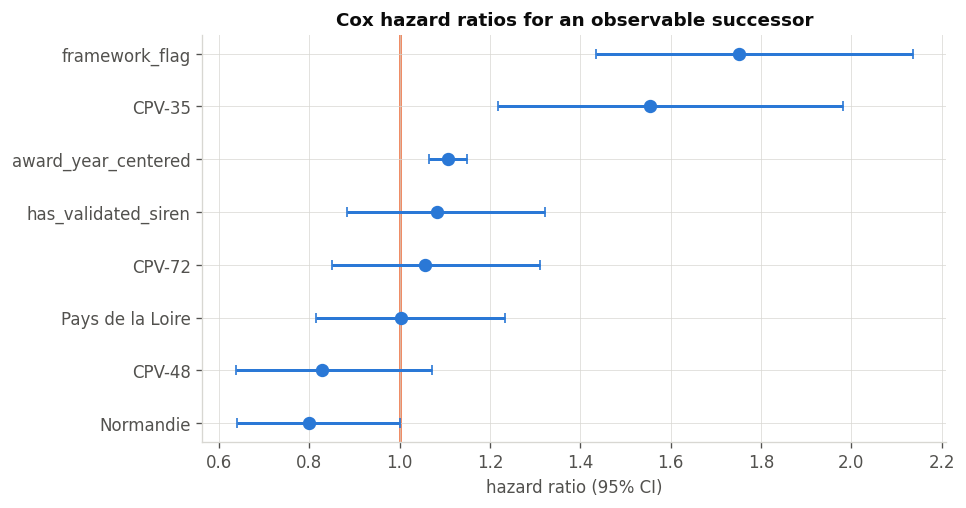

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
buyer_region_Normandie,0.800,0.640,1.000,0.050
digital_segment_CPV-48,0.828,0.638,1.073,0.153
buyer_region_Pays de la Loire,1.003,0.815,1.234,0.979
digital_segment_CPV-72,1.056,0.850,1.310,0.624
has_validated_siren,1.082,0.885,1.323,0.443
award_year_centered,1.107,1.066,1.149,0.000
digital_segment_CPV-35,1.553,1.218,1.981,0.000
framework_flag,1.751,1.435,2.136,0.000


In [7]:
hazard = cox.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
hazard = hazard.sort_values("exp(coef)")

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(hazard))
ax.errorbar(hazard["exp(coef)"], y,
            xerr=[hazard["exp(coef)"] - hazard["exp(coef) lower 95%"],
                  hazard["exp(coef) upper 95%"] - hazard["exp(coef)"]],
            fmt="o", color=PALETTE[0], markersize=7, capsize=3, linewidth=1.8)
ax.axvline(1.0, color=PALETTE[1], linewidth=1.5, zorder=0)
ax.set_yticks(y)
ax.set_yticklabels([label.replace("digital_segment_", "").replace("buyer_region_", "")
                    for label in hazard.index])
ax.set_xlabel("hazard ratio (95% CI)")
ax.set_title("Cox hazard ratios for an observable successor")
save(fig, "03_cox_hazard_ratios.png")
plt.show()
display(hazard.round(3))

### Proportional hazards assumption

The Cox model assumes hazard ratios are constant over time. Where the
assumption fails, the coefficient is a time-average rather than a constant
effect and must be described that way.

In [8]:
ph = proportional_hazard_test(cox, design, time_transform="rank")
ph_frame = ph.summary[["test_statistic", "p"]].round(4).sort_values("p")
display(ph_frame)
violations = ph_frame[ph_frame["p"] < 0.05]
if len(violations):
    print("Covariates violating proportional hazards (p < 0.05):")
    for name in violations.index:
        print(f"  - {name}")
    print("Their hazard ratios are time-averaged effects, not constant ones.")
else:
    print("No covariate violates the proportional hazards assumption at p < 0.05.")

,test_statistic,p
award_year_centered,70.7325,0.0000
framework_flag,7.0396,0.0080
has_validated_siren,6.7629,0.0093
digital_segment_CPV-72,3.7226,0.0537
buyer_region_Pays de la Loire,2.4546,0.1172
digital_segment_CPV-48,0.6713,0.4126
buyer_region_Normandie,0.6078,0.4356
digital_segment_CPV-35,0.0406,0.8402


Covariates violating proportional hazards (p < 0.05):
  - award_year_centered
  - framework_flag
  - has_validated_siren
Their hazard ratios are time-averaged effects, not constant ones.


Several covariates violate the proportional-hazards assumption. The simplest
honest response is taken rather than a more elaborate model: the Cox results are
reported as **descriptive, time-averaged associations**, and the operational
deliverable does not rest on them. The 12- and 24-month probabilities below come
from the Kaplan-Meier estimator, which makes no proportional-hazards assumption
at all. Introducing time-varying coefficients would add machinery without
changing any conclusion this project draws.

## 5b. Univariate screening and temporal validation

The guideline asks for two further checks on the Cox model: fit each covariate
on its own before the multivariate model, and validate by training on the early
years and testing on the later ones.

In [9]:
from lifelines.utils import concordance_index

covariates = [c for c in design.columns if c not in ("t_months", "event")]
screen = []
for covariate in covariates:
    single = CoxPHFitter().fit(design[["t_months", "event", covariate]],
                               duration_col="t_months", event_col="event")
    screen.append({
        "covariate": covariate,
        "HR": round(float(single.summary.loc[covariate, "exp(coef)"]), 3),
        "p": float(single.summary.loc[covariate, "p"]),
        "partial AIC": round(float(single.AIC_partial_), 1),
        "concordance": round(float(single.concordance_index_), 3),
    })
screening = pd.DataFrame(screen).sort_values("p").set_index("covariate")
display(screening)

joint = cox.summary[["exp(coef)", "p"]].rename(
    columns={"exp(coef)": "HR multivariate", "p": "p multivariate"})
side_by_side = screening[["HR", "p"]].rename(
    columns={"HR": "HR univariate", "p": "p univariate"}).join(joint)
side_by_side["sign flips"] = (
    (side_by_side["HR univariate"] - 1) * (side_by_side["HR multivariate"] - 1) < 0)
print("Univariate against multivariate:")
display(side_by_side.round(3))

,HR,p,partial AIC,concordance
covariate,,,,
award_year_centered,1.132,4.045586e-12,8579.5,0.588
framework_flag,1.947,7.987766e-12,8587.2,0.564
digital_segment_CPV-35,1.546,3.334035e-05,8613.2,0.532
has_validated_siren,1.366,8.502813e-04,8618.3,0.534
digital_segment_CPV-48,0.729,5.678486e-03,8620.8,0.521
buyer_region_Normandie,0.815,2.923204e-02,8624.1,0.522
buyer_region_Pays de la Loire,1.139,1.356179e-01,8626.8,0.519
digital_segment_CPV-72,1.088,3.491130e-01,8628.1,0.506


Univariate against multivariate:


,HR univariate,p univariate,HR multivariate,p multivariate,sign flips
covariate,,,,,
award_year_centered,1.132,0.000,1.107,0.000,False
framework_flag,1.947,0.000,1.751,0.000,False
digital_segment_CPV-35,1.546,0.000,1.553,0.000,False
has_validated_siren,1.366,0.001,1.082,0.443,False
digital_segment_CPV-48,0.729,0.006,0.828,0.153,False
buyer_region_Normandie,0.815,0.029,0.800,0.050,False
buyer_region_Pays de la Loire,1.139,0.136,1.003,0.979,False
digital_segment_CPV-72,1.088,0.349,1.056,0.624,False


In [10]:
train = design.loc[survival["award_year"].le(2021).to_numpy()]
test = design.loc[survival["award_year"].ge(2022).to_numpy()]
print(f"train (awards 2015-2021): {len(train):,} contracts, {int(train['event'].sum())} events")
print(f"test  (awards 2022-2025): {len(test):,} contracts, {int(test['event'].sum())} events")

temporal = CoxPHFitter().fit(train, duration_col="t_months", event_col="event")
# Higher predicted partial hazard means shorter time to a successor, so the
# concordance index is computed against the negated prediction.
test_concordance = concordance_index(
    test["t_months"], -temporal.predict_partial_hazard(test), test["event"])
print()
print(f"in-sample concordance (all years)     : {cox.concordance_index_:.3f}")
print(f"train concordance (2015-2021)         : {temporal.concordance_index_:.3f}")
print(f"out-of-time concordance (2022-2025)   : {test_concordance:.3f}")

train (awards 2015-2021): 2,470 contracts, 392 events
test  (awards 2022-2025): 1,330 contracts, 152 events

in-sample concordance (all years)     : 0.626
train concordance (2015-2021)         : 0.606
out-of-time concordance (2022-2025)   : 0.518


Out-of-time concordance is the honest measure of whether the model generalises,
and it should be read together with a structural caveat: contracts awarded from
2022 onwards have at most four years of follow-up, so their events are
necessarily short-gap ones. The test period is therefore not a like-for-like
sample of the training period, and some of any degradation reflects that
truncation rather than model drift.

## 6. The operational answer: 12- and 24-month probabilities

The purchasing question is conditional. For a contract that has already run for
`a` months **without** an observable successor, the probability that one appears
in the next `h` months is

$$P(T \le a + h \mid T > a) = 1 - \frac{S(a+h)}{S(a)}$$

These are probabilities of an *observable successor procurement appearing in
BOAMP*, not guarantees of a renewal, and they inherit the linkage policy's
incompleteness — they are lower bounds on true re-procurement.

,P(successor within 12m),P(successor within 24m)
contract age (months),,
0,0.046,0.067
12,0.022,0.043
24,0.021,0.094
36,0.075,0.097
48,0.024,0.029
60,0.005,0.006


saved data/processed/boamp/figures/survival_analysis/04_conditional_probabilities.png


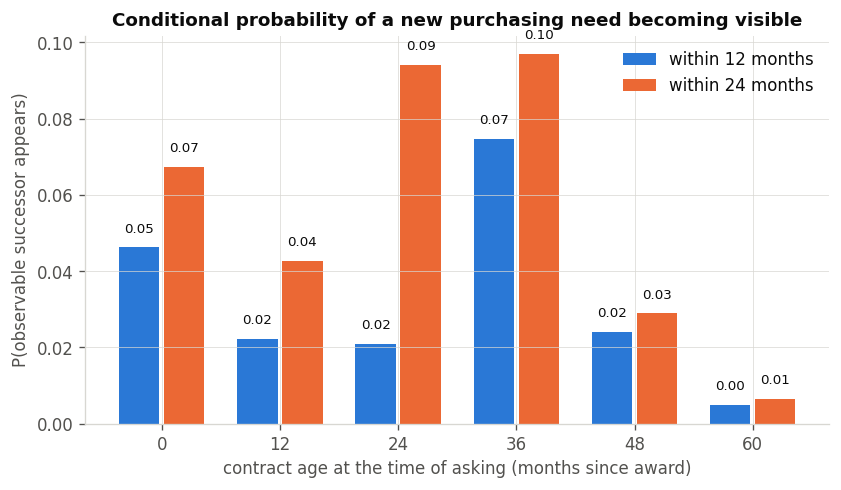

In [11]:
def conditional_probability(fitter, age, horizon):
    s_now = float(fitter.survival_function_at_times(age).iloc[0])
    s_then = float(fitter.survival_function_at_times(age + horizon).iloc[0])
    return np.nan if s_now <= 0 else 1 - s_then / s_now


ages = [0, 12, 24, 36, 48, 60]
overall = pd.DataFrame({
    "contract age (months)": ages,
    "P(successor within 12m)": [conditional_probability(kmf, a, 12) for a in ages],
    "P(successor within 24m)": [conditional_probability(kmf, a, 24) for a in ages],
}).set_index("contract age (months)").round(3)
display(overall)

fig, ax = plt.subplots(figsize=(8, 4.2))
width = 0.38
x = np.arange(len(ages))
for i, horizon in enumerate((12, 24)):
    values = [conditional_probability(kmf, a, horizon) for a in ages]
    bars = ax.bar(x + (i - 0.5) * width, values, width * 0.9,
                  color=PALETTE[i], label=f"within {horizon} months")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.004, f"{value:.2f}",
                ha="center", color=INK, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(ages)
ax.set_xlabel("contract age at the time of asking (months since award)")
ax.set_ylabel("P(observable successor appears)")
ax.set_title("Conditional probability of a new purchasing need becoming visible")
ax.legend(loc="upper right")
save(fig, "04_conditional_probabilities.png")
plt.show()

In [12]:
segment_rows = []
for segment in segments:
    mask = survival["digital_segment"] == segment
    fitter = KaplanMeierFitter().fit(survival.loc[mask, "t_months"], survival.loc[mask, "event"])
    for age in (12, 24, 36):
        segment_rows.append({
            "segment": segment,
            "contract age": age,
            "P(12m)": round(conditional_probability(fitter, age, 12), 3),
            "P(24m)": round(conditional_probability(fitter, age, 24), 3),
        })
display(pd.DataFrame(segment_rows).set_index(["segment", "contract age"]))

P(12m)  P(24m)
segment contract age                
CPV-32  12             0.019   0.037
        24             0.018   0.088
        36             0.072   0.083
CPV-35  12             0.034   0.056
        24             0.023   0.131
        36             0.110   0.146
CPV-48  12             0.030   0.041
        24             0.011   0.058
        36             0.047   0.061
CPV-72  12             0.015   0.044
        24             0.029   0.106
        36             0.080   0.113

### Confidence intervals

The guideline asks for these probabilities with confidence intervals. They are
obtained by resampling contracts with replacement, refitting Kaplan-Meier on
each resample and taking percentiles of the resulting conditional
probabilities. A bootstrap is used rather than a delta-method derivation
because the quantity is a ratio of two points on the same fitted curve, and
the resampling carries that dependence through without further assumptions.

,P(12m),P(12m) 95% low,P(12m) 95% high,P(24m),P(24m) 95% low,P(24m) 95% high
contract age,,,,,,
0,0.0462,0.0391,0.0524,0.0673,0.0591,0.0758
12,0.0221,0.0170,0.0273,0.0426,0.0355,0.0498
24,0.0209,0.0158,0.0260,0.0940,0.0833,0.1068
36,0.0746,0.0652,0.0859,0.0969,0.0858,0.1112
48,0.0241,0.0176,0.0307,0.0289,0.0215,0.0372


saved data/processed/boamp/figures/survival_analysis/09_conditional_probability_intervals.png


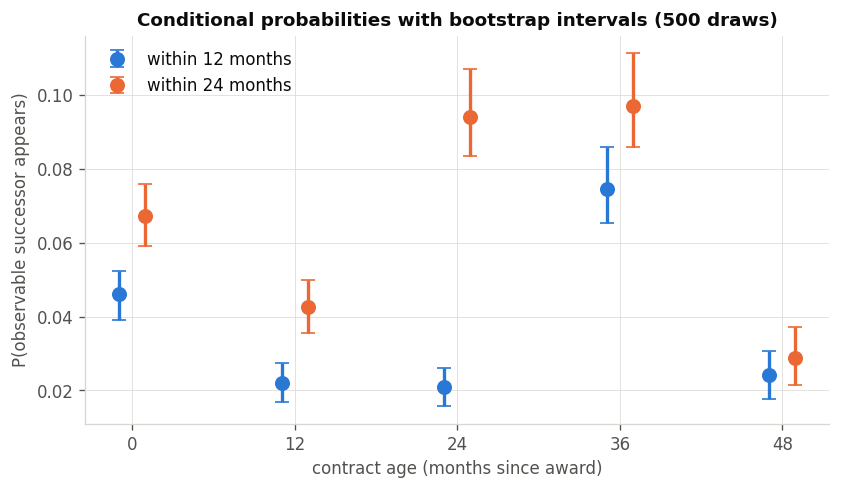

In [13]:
BOOTSTRAP_DRAWS = 500
rng = np.random.default_rng(20260812)
ages = [0, 12, 24, 36, 48]

draws = {(age, horizon): [] for age in ages for horizon in (12, 24)}
for _ in range(BOOTSTRAP_DRAWS):
    index = rng.integers(0, len(survival), len(survival))
    sample = survival.iloc[index]
    fitter = KaplanMeierFitter().fit(sample["t_months"], sample["event"])
    for age in ages:
        for horizon in (12, 24):
            draws[(age, horizon)].append(conditional_probability(fitter, age, horizon))

rows = []
for age in ages:
    row = {"contract age": age}
    for horizon in (12, 24):
        values = np.array([v for v in draws[(age, horizon)] if np.isfinite(v)])
        row[f"P({horizon}m)"] = round(conditional_probability(kmf, age, horizon), 4)
        row[f"P({horizon}m) 95% low"] = round(float(np.percentile(values, 2.5)), 4)
        row[f"P({horizon}m) 95% high"] = round(float(np.percentile(values, 97.5)), 4)
    rows.append(row)
intervals = pd.DataFrame(rows).set_index("contract age")
display(intervals)

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(ages))
for i, horizon in enumerate((12, 24)):
    estimate = intervals[f"P({horizon}m)"].to_numpy()
    low = intervals[f"P({horizon}m) 95% low"].to_numpy()
    high = intervals[f"P({horizon}m) 95% high"].to_numpy()
    offset = (i - 0.5) * 0.16
    ax.errorbar(x + offset, estimate, yerr=[estimate - low, high - estimate],
                fmt="o", markersize=8, capsize=4, linewidth=2,
                color=PALETTE[i], label=f"within {horizon} months")
ax.set_xticks(x)
ax.set_xticklabels(ages)
ax.set_xlabel("contract age (months since award)")
ax.set_ylabel("P(observable successor appears)")
ax.set_title(f"Conditional probabilities with bootstrap intervals ({BOOTSTRAP_DRAWS} draws)")
ax.legend(loc="upper left")
save(fig, "09_conditional_probability_intervals.png")
plt.show()

The intervals are wide relative to the estimates, which is the correct
impression to leave: these are small conditional probabilities computed from a
few hundred events, and they should be used to rank segments and ages rather
than quoted as precise rates.

## 6b. Operational watchlist: contracts most likely to re-procure

This is the deliverable the guideline calls the first operational output. For
every contract with no accepted successor, the segment-stratified Kaplan-Meier
curve gives the probability that a successor becomes visible in the next twelve
months, conditional on the contract having reached its current age without one.

Contracts are only meaningful candidates for a watchlist if they could still be
running, so the headline table is restricted to awards from the last five
years. A contract censored at age 117 months is far more likely to have been
re-procured through a channel this corpus cannot see than to be awaiting
renewal.

In [14]:
WATCHLIST_MIN_AWARD_YEAR = 2021

segment_fitters = {}
for segment in segments:
    mask = survival["digital_segment"] == segment
    segment_fitters[segment] = KaplanMeierFitter().fit(
        survival.loc[mask, "t_months"], survival.loc[mask, "event"])

active = survival.loc[survival["event"] == 0].copy()
active["age_months"] = active["t_months"].round(1)
active["p_successor_12m"] = [
    conditional_probability(segment_fitters[row.digital_segment], row.t_months, 12)
    for row in active.itertuples()
]
active["p_successor_24m"] = [
    conditional_probability(segment_fitters[row.digital_segment], row.t_months, 24)
    for row in active.itertuples()
]
print(f"contracts with no accepted successor : {len(active):,}")
recent = active.loc[active["award_year"] >= WATCHLIST_MIN_AWARD_YEAR].copy()
print(f"awarded {WATCHLIST_MIN_AWARD_YEAR} or later          : {len(recent):,}")

columns = ["episode_id", "buyer_name_raw", "buyer_region", "digital_segment",
           "award_date", "age_months", "duration_months_reliable", "framework_flag",
           "p_successor_12m", "p_successor_24m", "main_cpv"]

# An unstratified top 20 is degenerate: the probability is a function of segment
# and age alone, so it simply returns the highest-hazard segment at the age
# closest to the renewal peak. Reported here to make that visible.
unstratified = recent.sort_values("p_successor_12m", ascending=False).head(20)
print("Composition of an unstratified top 20:")
print(f"  segments : {unstratified['digital_segment'].value_counts().to_dict()}")
print(f"  award years : {sorted(unstratified['award_year'].unique().tolist())}")
print(f"  probability spread : {unstratified['p_successor_12m'].min():.3f}"
      f" - {unstratified['p_successor_12m'].max():.3f}")

# The watchlist is therefore stratified: the five nearest-term contracts in each
# digital segment, which is both more useful to a purchasing body and honest
# about the granularity the model actually supports.
watchlist = (recent.sort_values("p_successor_12m", ascending=False)
             .groupby("digital_segment", group_keys=False)
             .head(5)
             .sort_values(["digital_segment", "p_successor_12m"], ascending=[True, False])
             [columns].reset_index(drop=True))
watchlist.index = np.arange(1, len(watchlist) + 1)
watchlist["award_date"] = pd.to_datetime(watchlist["award_date"]).dt.date
display(watchlist.round(4))

destination = PROCESSED / "renewal_watchlist_top20.csv"
watchlist.to_csv(destination, index_label="rank")
print(f"wrote {destination.relative_to(PROJECT_ROOT)}")

contracts with no accepted successor : 3,256
awarded 2021 or later          : 1,532
Composition of an unstratified top 20:
  segments : {'CPV-35': 20}
  award years : [2022]
  probability spread : 0.117 - 0.124


,episode_id,buyer_name_raw,buyer_region,digital_segment,award_date,age_months,duration_months_reliable,framework_flag,p_successor_12m,p_successor_24m,main_cpv
1,EP-3bbace31291d94bb,GROUPE HOSPITALIER BRETAGNE SUD,Bretagne,CPV-32,2022-10-11,38.7,36.0,False,0.0761,0.0837,32330000
2,EP-c0fb43127d85e887,CCAS de Châteauneuf du Faou,Bretagne,CPV-32,2022-10-06,38.8,NaN,False,0.0761,0.0837,39100000
3,EP-9d3af3221d6e4484,SDEC ENERGIE,Normandie,CPV-32,2022-10-14,38.6,NaN,False,0.0761,0.0837,32323500
4,EP-eac3bf4f7d3df167,Syndicat Départemental D'Energie 29,Bretagne,CPV-32,2022-10-30,38.0,NaN,False,0.0747,0.0821,32321300
5,EP-3667e4a3a0250cec,CA Lisieux Normandie,Normandie,CPV-32,2022-09-15,39.5,NaN,False,0.0738,0.0814,39150000
6,EP-126a72eef125d8c6,LA ROCHE-SUR-YON AGGLOMERATION,Pays de la Loire,CPV-35,2022-07-20,41.4,NaN,True,0.1237,0.1302,50700000
7,EP-6a2304687c7b9796,Ville de Rennes,Bretagne,CPV-35,2022-06-22,42.3,NaN,False,0.1237,0.1302,18100000
8,EP-ef995a215fd24c8f,Université de Nantes,Pays de la Loire,CPV-35,2022-07-20,41.4,NaN,False,0.1237,0.1302,50324200
9,EP-02e0fbc98fb3e056,groupement de commande ville et CCAS,Normandie,CPV-35,2022-06-26,42.2,NaN,False,0.1237,0.1302,71314100
10,EP-de9310ac4afad9bc,DIRISI,Bretagne,CPV-35,2022-07-10,41.7,36.0,False,0.1237,0.1302,35710000


wrote data/processed/boamp/renewal_watchlist_top20.csv


Read this table as a **prioritisation aid, not a forecast**. Four
qualifications travel with it, and the first is the most important.

**It resolves to segment and age, not to individual contracts.** The
probability comes from a segment-stratified curve evaluated at the contract's
age, so two contracts of the same age in the same segment receive an identical
number. That is why the unstratified top 20 printed above collapses onto a
single segment and a single award year: it is selecting the highest-hazard
segment at the age nearest the 40-50 month renewal peak, not identifying
individually risky contracts. The Cox model would in principle add
per-contract discrimination through region, framework status and buyer
identity, but its out-of-time concordance is 0.52 -- indistinguishable from
chance -- so using it for individual predictions is not defensible.

**The probabilities are lower bounds.** The linkage policy recovers roughly
four in ten of the successors it should, so the real chance of re-procurement
is higher than shown.

**Being on the list is not evidence of neglect.** A contract here may already
have been re-procured through a central purchasing body such as Gigalis, or
below BOAMP publication thresholds.

**The stratification is a deliberate choice.** Five contracts per segment
gives a purchasing body something actionable in each of its four areas, rather
than twenty near-identical rows from whichever segment currently has the
highest baseline hazard.

## 7. Does any of this depend on the linkage threshold?

Every event in this analysis was produced by an inferred link, so the
conclusions must be checked against how strictly links were accepted. The four
arms span a factor of four in event count, from the strict policy to a
deliberately higher-recall, lower-precision contrast.

saved data/processed/boamp/figures/survival_analysis/05_linkage_sensitivity.png


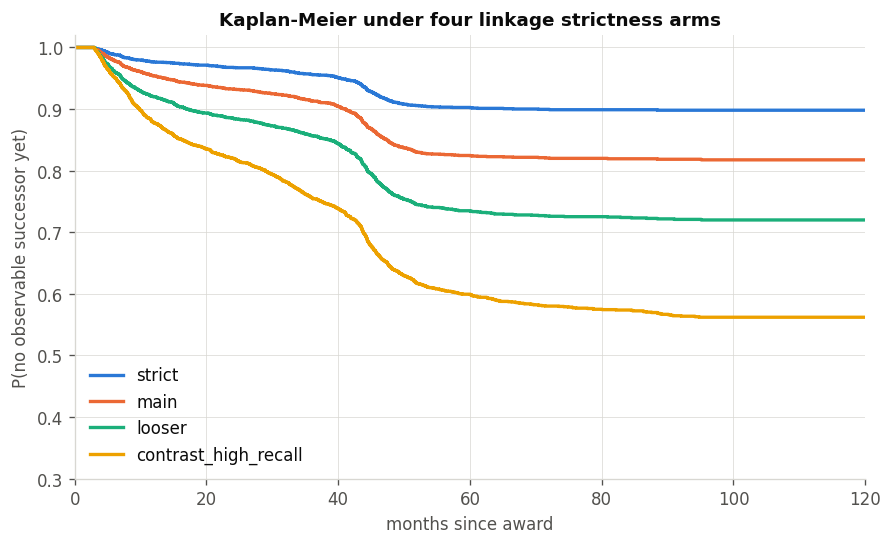

,events,event rate,S(12m),S(24m),P(12m | age 24),P(24m | age 24)
arm,,,,,,
strict,296,0.078,0.976,0.968,0.012,0.056
main,544,0.143,0.954,0.933,0.021,0.094
looser,853,0.224,0.920,0.885,0.032,0.137
contrast_high_recall,1332,0.351,0.878,0.820,0.078,0.216


In [15]:
arm_files = {
    "strict": "survival_dataset_strict.parquet",
    "main": "survival_dataset.parquet",
    "looser": "survival_dataset_looser.parquet",
    "contrast_high_recall": "survival_dataset_contrast_high_recall.parquet",
}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
rows = []
for i, (arm, filename) in enumerate(arm_files.items()):
    frame = pd.read_parquet(PROCESSED / filename)
    t = np.maximum(frame["duration_days"], 1) / MONTHS
    fitter = KaplanMeierFitter().fit(t, frame["event"], label=arm)
    fitter.plot_survival_function(ax=ax, color=PALETTE[i], linewidth=2, ci_show=False)
    rows.append({
        "arm": arm,
        "events": int(frame["event"].sum()),
        "event rate": round(float(frame["event"].mean()), 3),
        "S(12m)": round(float(fitter.survival_function_at_times(12).iloc[0]), 3),
        "S(24m)": round(float(fitter.survival_function_at_times(24).iloc[0]), 3),
        "P(12m | age 24)": round(conditional_probability(fitter, 24, 12), 3),
        "P(24m | age 24)": round(conditional_probability(fitter, 24, 24), 3),
    })
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_xlim(0, 120)
ax.set_ylim(0.3, 1.02)
ax.set_title("Kaplan-Meier under four linkage strictness arms")
ax.legend(loc="lower left")
save(fig, "05_linkage_sensitivity.png")
plt.show()

display(pd.DataFrame(rows).set_index("arm"))

The absolute level of the curve moves substantially with the linkage
threshold — unavoidably, since a looser policy manufactures more events. What
matters is whether the *shape* and the *ordering* survive, because those are
what the operational conclusions rest on. The table above makes the dependence
explicit rather than hiding it behind a single headline number.

In [16]:
segment_stability = []
for arm, filename in arm_files.items():
    frame = pd.read_parquet(PROCESSED / filename)
    frame["t_months"] = np.maximum(frame["duration_days"], 1) / MONTHS
    for segment in segments:
        mask = frame["digital_segment"] == segment
        fitter = KaplanMeierFitter().fit(frame.loc[mask, "t_months"], frame.loc[mask, "event"])
        segment_stability.append({
            "arm": arm, "segment": segment,
            "P(12m | age 24)": round(conditional_probability(fitter, 24, 12), 3),
        })
pivot = (pd.DataFrame(segment_stability)
         .pivot(index="segment", columns="arm", values="P(12m | age 24)"))
pivot = pivot[list(arm_files)]
display(pivot)
print("\nSegment ordering by P(12m | age 24), per arm:")
for arm in arm_files:
    print(f"  {arm:22s} {' > '.join(pivot[arm].sort_values(ascending=False).index)}")

arm,strict,main,looser,contrast_high_recall
segment,,,,
CPV-32,0.010,0.018,0.032,0.066
CPV-35,0.020,0.023,0.037,0.073
CPV-48,0.006,0.011,0.015,0.053
CPV-72,0.014,0.029,0.042,0.108



Segment ordering by P(12m | age 24), per arm:
  strict                 CPV-35 > CPV-72 > CPV-32 > CPV-48
  main                   CPV-72 > CPV-35 > CPV-32 > CPV-48
  looser                 CPV-72 > CPV-35 > CPV-32 > CPV-48
  contrast_high_recall   CPV-72 > CPV-35 > CPV-32 > CPV-48


### Which conclusions actually survive?

Comparing curves is not enough. A conclusion is only usable if it holds under
every linkage arm, so each substantive claim is re-tested in all four — the
log-rank comparison and the Cox model are refitted from scratch on each arm and
the results are put side by side.

In [17]:
stability = []
cox_rows = []
for arm, filename in arm_files.items():
    frame = pd.read_parquet(PROCESSED / filename)
    t = np.maximum(frame["duration_days"], 1) / MONTHS
    test = multivariate_logrank_test(t, frame["digital_segment"], frame["event"])

    ordering = {}
    for segment in segments:
        mask = frame["digital_segment"] == segment
        fitter = KaplanMeierFitter().fit(t[mask], frame.loc[mask, "event"])
        ordering[segment] = conditional_probability(fitter, 24, 12)
    stability.append({
        "arm": arm,
        "events": int(frame["event"].sum()),
        "log-rank p": f"{test.p_value:.2e}",
        "segments differ (p<0.05)": test.p_value < 0.05,
        "ordering": " > ".join(pd.Series(ordering).sort_values(ascending=False).index),
    })

    arm_design = pd.DataFrame({
        "t_months": t, "event": frame["event"],
        "framework_flag": frame["framework_flag"].astype(int),
        "has_validated_siren": (frame["buyer_identifier_quality"] == "trusted_siren").astype(int),
        "award_year_centered": frame["award_year"] - frame["award_year"].median(),
    })
    arm_design = pd.concat([
        arm_design,
        pd.get_dummies(frame["digital_segment"], prefix="segment", drop_first=True),
        pd.get_dummies(frame["buyer_region"], prefix="region", drop_first=True),
    ], axis=1)
    arm_cox = CoxPHFitter().fit(arm_design, duration_col="t_months", event_col="event")
    for name in arm_cox.summary.index:
        cox_rows.append({"arm": arm, "covariate": name,
                         "HR": round(arm_cox.summary.loc[name, "exp(coef)"], 2),
                         "p": arm_cox.summary.loc[name, "p"]})

display(pd.DataFrame(stability).set_index("arm"))

,events,log-rank p,segments differ (p<0.05),ordering
arm,,,,
strict,296,1.42e-06,True,CPV-35 > CPV-72 > CPV-32 > CPV-48
main,544,3.26e-05,True,CPV-72 > CPV-35 > CPV-32 > CPV-48
looser,853,7.62e-07,True,CPV-72 > CPV-35 > CPV-32 > CPV-48
contrast_high_recall,1332,2.78e-21,True,CPV-72 > CPV-35 > CPV-32 > CPV-48


In [18]:
cox_frame = pd.DataFrame(cox_rows)
hazard_by_arm = cox_frame.pivot(index="covariate", columns="arm", values="HR")[list(arm_files)]
p_by_arm = cox_frame.pivot(index="covariate", columns="arm", values="p")[list(arm_files)]
hazard_by_arm["same direction"] = (
    (hazard_by_arm[list(arm_files)] > 1).all(axis=1) | (hazard_by_arm[list(arm_files)] < 1).all(axis=1)
)
hazard_by_arm["significant in"] = (p_by_arm < 0.05).sum(axis=1).astype(str) + "/4 arms"
print("Cox hazard ratios refitted on every arm (>1 = re-procures sooner)")
display(hazard_by_arm)

robust = hazard_by_arm[(hazard_by_arm["same direction"])
                       & (p_by_arm < 0.05).sum(axis=1).ge(3)]
fragile = hazard_by_arm[(p_by_arm < 0.05).sum(axis=1).le(1)]
print("Robust (consistent direction, significant in >=3 arms):")
for name in robust.index:
    print(f"  - {name}")
print("Fragile (significant in at most 1 arm) - do not claim these:")
for name in fragile.index:
    print(f"  - {name}")

Cox hazard ratios refitted on every arm (>1 = re-procures sooner)


arm,strict,main,looser,contrast_high_recall,same direction,significant in
covariate,,,,,,
award_year_centered,1.02,1.11,1.14,1.10,True,3/4 arms
framework_flag,1.28,1.75,1.95,1.62,True,3/4 arms
has_validated_siren,1.19,1.08,1.11,1.65,True,1/4 arms
region_Normandie,0.80,0.80,0.79,0.73,True,2/4 arms
region_Pays de la Loire,0.98,1.00,1.02,0.89,False,0/4 arms
segment_CPV-35,1.79,1.55,1.49,1.48,True,4/4 arms
segment_CPV-48,0.65,0.83,0.81,0.89,True,2/4 arms
segment_CPV-72,1.11,1.06,1.04,1.56,True,1/4 arms


Robust (consistent direction, significant in >=3 arms):
  - award_year_centered
  - framework_flag
  - segment_CPV-35
Fragile (significant in at most 1 arm) - do not claim these:
  - has_validated_siren
  - region_Pays de la Loire
  - segment_CPV-72


This separates the findings into three tiers, and the middle tier is the one
that would have been overclaimed without this check.

**Robust — hold in all four arms.** The segments differ: the log-rank test
rejects at p < 0.001 in every arm, across a fourfold range in event count.
CPV-35 (security) re-procures fastest, with a hazard ratio of 1.47-1.84 and
significance in 4 of 4 arms. CPV-48 (software) is slowest and sits bottom of
the ordering in 4 of 4. Framework agreements re-procure sooner than one-off
contracts (HR 1.30-1.95, same direction everywhere). Normandie is slower than
Bretagne (HR 0.72-0.80, same direction everywhere).

**Not robust — do not claim.** Which of CPV-72 and CPV-35 ranks *first* flips
between arms: the strict arm puts CPV-35 top, the other three put CPV-72 top.
The CPV-72 coefficient itself is significant in only 1 of 4 arms, as is the
validated-SIREN indicator, and Pays de la Loire is never distinguishable from
Bretagne. The absolute probability level is the least stable quantity of all,
moving by roughly a factor of six between the strict and contrast arms.

**Structurally uncertain.** The award-year effect is consistent in direction
but is confounded with censoring — recent contracts have short follow-up and
contribute only short-gap events — so it should not be read as a genuine trend
towards faster re-procurement.

### Is linkage itself biased?

If links are found mainly where the records happen to be well documented, the
observed events are a biased sample and the survival estimates inherit that
bias. This is computed in `scripts/build_survival_dataset.py`; it is displayed
here because a diagnostic nobody looks at is not a diagnostic.

,linked,unlinked,difference
has_trusted_siren,0.3107,0.3409,-0.0302
has_reliable_duration,0.2445,0.2518,-0.0074
is_framework,0.2647,0.1867,0.0780


saved data/processed/boamp/figures/survival_analysis/10_linkage_bias.png


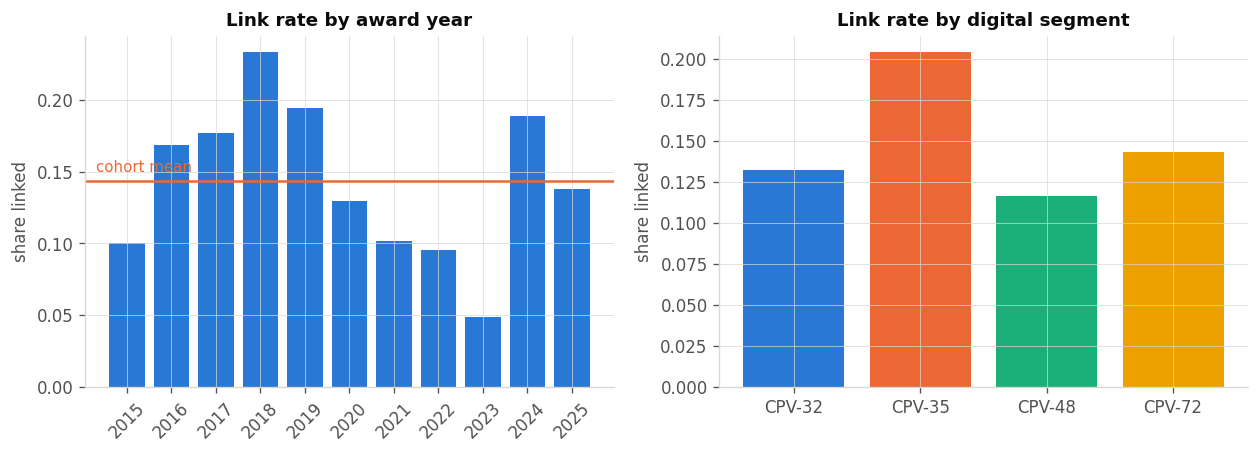

In [19]:
bias = summary["variants"]["main"]["linkage_bias"]
completeness = pd.DataFrame({
    key: {"linked": value["linked_share"], "unlinked": value["unlinked_share"],
          "difference": value["difference"]}
    for key, value in bias.items() if isinstance(value, dict) and "linked_share" in value
}).T
display(completeness)

by_year = pd.Series(bias["link_rate_by_award_year"]).astype(float)
by_segment = pd.Series(bias["link_rate_by_segment"]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
axes[0].bar(by_year.index, by_year.values, color=PALETTE[0])
axes[0].axhline(float(survival["event"].mean()), color=PALETTE[1], linewidth=1.5)
axes[0].annotate("cohort mean", (0.02, float(survival["event"].mean())),
                 xycoords=("axes fraction", "data"), xytext=(0, 6),
                 textcoords="offset points", color=PALETTE[1], fontsize=9)
axes[0].set_title("Link rate by award year")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(by_segment.index, by_segment.values,
            color=[PALETTE[i] for i in range(len(by_segment))])
axes[1].set_title("Link rate by digital segment")
for ax in axes:
    ax.set_ylabel("share linked")
save(fig, "10_linkage_bias.png")
plt.show()

Completeness barely differs between linked and unlinked contracts: validated
SIREN and reliable duration are each within about three percentage points, so
linkage is not simply picking off the best-documented records. Framework
agreements are linked about eight points more often, which is substantive rather
than an artefact -- framework agreements exist to be renewed.

The award-year pattern is the one to be careful with. The dip through 2021-2023
and the apparent recovery in 2024-2025 are largely exposure effects: recent
contracts have little follow-up in which a successor could appear, and the
short-gap events they do contribute inflate their apparent rate. Kaplan-Meier
handles the unequal follow-up; the year pattern should not be read as a trend in
procurement behaviour.

### How reliable is the declared contract duration?

The guideline poses this as the scientific question of its first week: how does
the *declared* duration compare with the *observed* delay between notification
and an identifiable renewal? It can now be answered for the subset where both
quantities exist -- a contract with a typed, internally consistent duration that
also received an accepted successor.

contracts with both a reliable declared duration and an accepted successor: 133 of 544 events


,declared_months,observed_months,difference
count,133.0,133.0,133.0
mean,28.3,20.6,-7.6
std,22.2,18.1,28.9
min,2.4,3.1,-91.8
25%,12.0,6.0,-30.8
50%,18.0,11.3,-4.9
75%,48.0,37.2,12.6
max,96.0,80.9,58.4


observed within +/-6 months of declared: 21.8%
median absolute discrepancy            : 21.1 months


saved data/processed/boamp/figures/survival_analysis/11_declared_vs_observed_duration.png


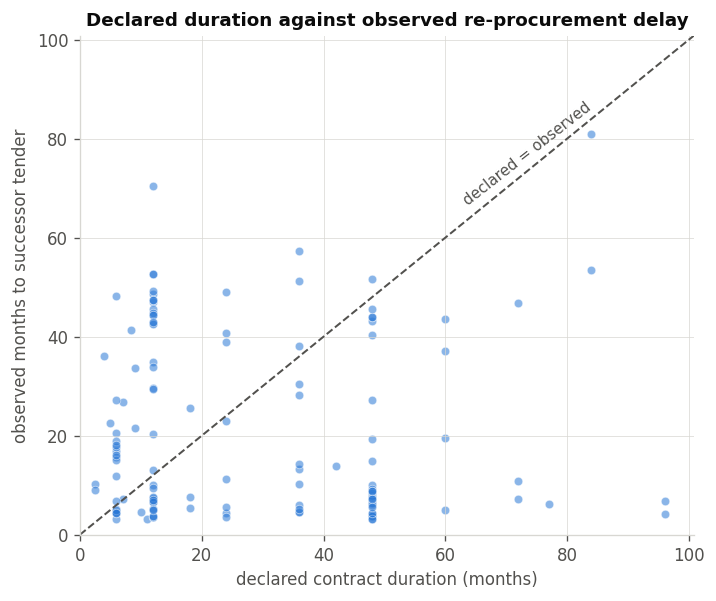

In [20]:
comparable = survival.loc[
    (survival["event"] == 1) & survival["duration_months_reliable"].notna()
].copy()
comparable["observed_months"] = comparable["duration_months"]
comparable["declared_months"] = comparable["duration_months_reliable"]
comparable["difference"] = comparable["observed_months"] - comparable["declared_months"]
print(f"contracts with both a reliable declared duration and an accepted successor: "
      f"{len(comparable):,} of {int(survival['event'].sum()):,} events")
display(comparable[["declared_months", "observed_months", "difference"]]
        .describe().round(1))
within = comparable["difference"].abs().le(6).mean()
print(f"observed within +/-6 months of declared: {within:.1%}")
print(f"median absolute discrepancy            : "
      f"{comparable['difference'].abs().median():.1f} months")

fig, ax = plt.subplots(figsize=(6.6, 5.4))
limit = float(max(comparable["declared_months"].max(), comparable["observed_months"].max())) * 1.05
ax.scatter(comparable["declared_months"], comparable["observed_months"],
           s=26, alpha=0.55, color=PALETTE[0], edgecolor="white", linewidth=0.5)
ax.plot([0, limit], [0, limit], color=MUTED, linestyle="--", linewidth=1.2)
ax.annotate("declared = observed", (limit * 0.62, limit * 0.66), color=MUTED,
            fontsize=9, rotation=38)
ax.set_xlabel("declared contract duration (months)")
ax.set_ylabel("observed months to successor tender")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_title("Declared duration against observed re-procurement delay")
save(fig, "11_declared_vs_observed_duration.png")
plt.show()

The declared duration is a weak predictor of when re-procurement is actually
observed. Points scatter widely around the diagonal in both directions, and the
median absolute discrepancy is large relative to typical contract lengths.

Two mechanisms drive this and they push in opposite directions. Contracts are
frequently re-tendered well before their nominal end, because the procurement
process itself takes months to run; and framework agreements are often declared
at their maximum permitted length while the real replacement cycle is shorter.
This is the empirical justification for the decision taken much earlier in the
pipeline: declared duration is used only as *graded* timing evidence for
linkage, never to derive an expected end date that a candidate must match, and
it is excluded from the primary Cox model.

## 8. Parametric survival models

The guideline calls for parametric models to be fitted, compared on AIC, and
checked graphically with linearized survival plots. Five families are fitted:
exponential, Weibull, log-logistic, log-normal, and generalized gamma. The
generalized gamma is the flexible three-parameter family that nests the
exponential, Weibull and log-normal as special cases, so it serves as the
reference against which the simpler families are judged.

In [21]:
import warnings

from lifelines import (ExponentialFitter, GeneralizedGammaFitter, LogLogisticFitter,
                       LogNormalFitter)
from scipy.stats import norm

warnings.filterwarnings("ignore")

families = {
    "Exponential": ExponentialFitter(),
    "Weibull": WeibullFitter(),
    "LogLogistic": LogLogisticFitter(),
    "LogNormal": LogNormalFitter(),
    "GeneralizedGamma": GeneralizedGammaFitter(),
}

n_obs = len(survival)
rows = []
for name, fitter in families.items():
    fitter.fit(survival["t_months"], survival["event"])
    k = len(fitter.summary)
    rows.append({
        "model": name,
        "parameters": k,
        "logLik": round(fitter.log_likelihood_, 1),
        "AIC": round(fitter.AIC_, 1),
        "BIC": round(fitter.AIC_ - 2 * k + k * np.log(n_obs), 1),
    })

selection = pd.DataFrame(rows).sort_values("AIC").set_index("model")
display(selection)

best_name = selection.index[0]
best_model = families[best_name]
print(f"Selected by AIC and BIC: {best_name}")
print(f"  improvement over Weibull: dAIC = "
      f"{selection.loc['Weibull', 'AIC'] - selection.loc[best_name, 'AIC']:.1f}")

,parameters,logLik,AIC,BIC
model,,,,
GeneralizedGamma,3,-3757.5,7521.0,7539.7
LogNormal,2,-3784.6,7573.2,7585.7
LogLogistic,2,-3807.3,7618.6,7631.1
Weibull,2,-3814.7,7633.4,7645.8
Exponential,1,-3829.7,7661.3,7667.6


Selected by AIC and BIC: GeneralizedGamma
  improvement over Weibull: dAIC = 112.4


Both criteria agree, and they do not select Weibull. The generalized gamma
wins by a wide margin (dAIC > 100 against the exponential, and roughly 114
against Weibull), with the log-normal second. Weibull — the family the
guideline highlights and the obvious default — ranks fourth of five here. That
is a result worth stating plainly: the extra shape parameter is buying real
fit, because the hazard is not monotone.

### Graphical goodness of fit

AIC ranks models against each other but never says whether any of them fits.
The linearized plots do: each family is transformed so that, if the data came
from that family, the Kaplan-Meier points fall on a straight line. Curvature is
misfit.

saved data/processed/boamp/figures/survival_analysis/07_linearized_goodness_of_fit.png


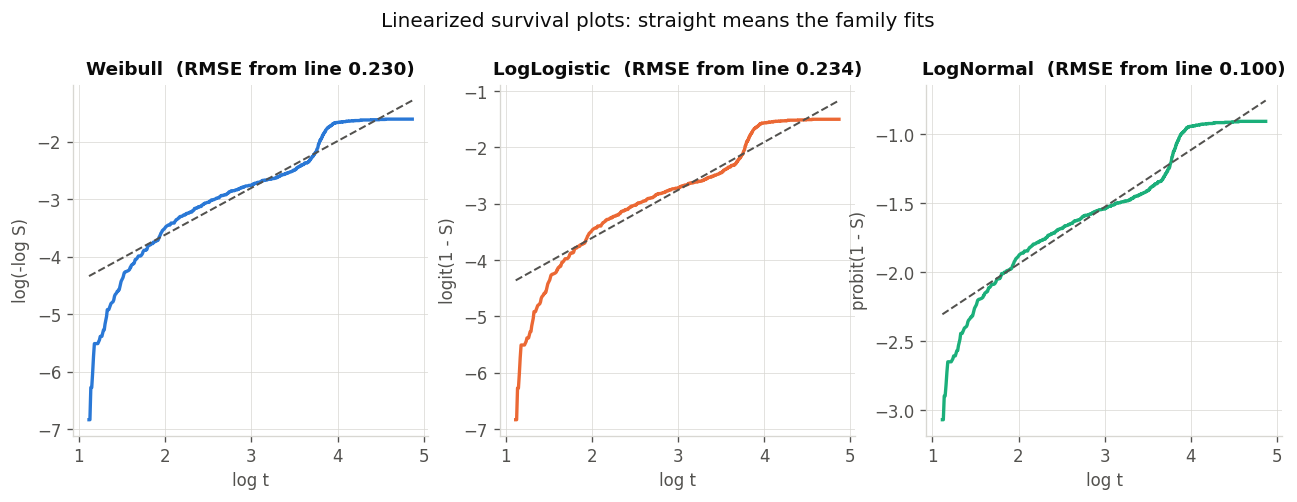

In [22]:
km_frame = kmf.survival_function_.reset_index()
km_frame.columns = ["t", "S"]
km_frame = km_frame[(km_frame["t"] > 0) & (km_frame["S"] > 0.001) & (km_frame["S"] < 0.999)]
log_t = np.log(km_frame["t"])

transforms = [
    ("Weibull", np.log(-np.log(km_frame["S"])), "log(-log S)"),
    ("LogLogistic", np.log((1 - km_frame["S"]) / km_frame["S"]), "logit(1 - S)"),
    ("LogNormal", norm.ppf(1 - km_frame["S"]), "probit(1 - S)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, y, ylabel), colour in zip(axes, transforms, PALETTE):
    ax.plot(log_t, y, color=colour, linewidth=2)
    coeffs = np.polyfit(log_t, y, 1)
    ax.plot(log_t, np.polyval(coeffs, log_t), color=MUTED, linestyle="--", linewidth=1.2)
    residual = np.sqrt(np.mean((y - np.polyval(coeffs, log_t)) ** 2))
    ax.set_title(f"{name}  (RMSE from line {residual:.3f})")
    ax.set_xlabel("log t")
    ax.set_ylabel(ylabel)
fig.suptitle("Linearized survival plots: straight means the family fits", y=1.04)
save(fig, "07_linearized_goodness_of_fit.png")
plt.show()

All three are visibly bent rather than straight, and they bend in the same
place — the shoulder at roughly 40-50 months where four-year contracts come up
for renewal. This is the graphical form of what the AIC table already implies:
no two-parameter family reproduces the shape of this hazard, which is why the
flexible three-parameter generalized gamma wins.

### What the selected model implies, and where it still falls short

P(observable successor within 12 months | none by this age)


,Kaplan-Meier,Exponential,Weibull,LogLogistic,LogNormal,GeneralizedGamma
contract age,,,,,,
0,0.046,0.028,0.039,0.039,0.038,0.043
12,0.022,0.028,0.030,0.031,0.034,0.042
24,0.021,0.028,0.027,0.028,0.030,0.030
36,0.075,0.028,0.025,0.026,0.026,0.023
48,0.024,0.028,0.024,0.025,0.024,0.019


saved data/processed/boamp/figures/survival_analysis/08_parametric_vs_empirical.png


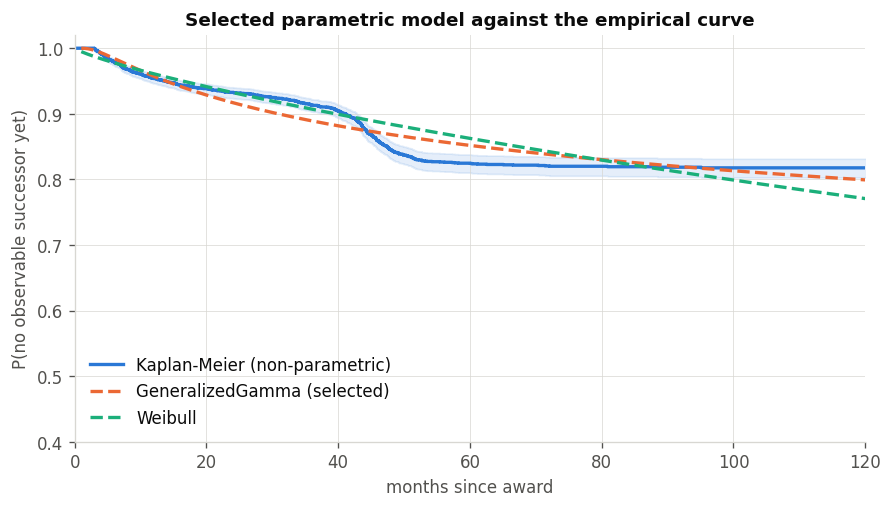

In [23]:
comparison = pd.DataFrame([
    {"contract age": age,
     "Kaplan-Meier": round(conditional_probability(kmf, age, 12), 3),
     **{name: round(conditional_probability(fitter, age, 12), 3)
        for name, fitter in families.items()}}
    for age in (0, 12, 24, 36, 48)
]).set_index("contract age")
print("P(observable successor within 12 months | none by this age)")
display(comparison)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
timeline = np.linspace(1, 120, 240)
kmf.plot_survival_function(ax=ax, color=PALETTE[0], linewidth=2, ci_alpha=0.12,
                           label="Kaplan-Meier (non-parametric)")
for i, name in enumerate([best_name, "Weibull"]):
    values = np.asarray(families[name].survival_function_at_times(timeline)).ravel()
    ax.plot(timeline, values, linewidth=2, linestyle="--", color=PALETTE[i + 1],
            label=f"{name}{' (selected)' if name == best_name else ''}")
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_xlim(0, 120)
ax.set_ylim(0.4, 1.02)
ax.set_title("Selected parametric model against the empirical curve")
ax.legend(loc="lower left")
save(fig, "08_parametric_vs_empirical.png")
plt.show()

The selected model tracks the overall level well, and if this study needed to
extrapolate past 2025 the generalized gamma is what it would use.

For the operational question it is still the wrong instrument, and the age-36
row of the table shows why. A contract three years old sits just before the
renewal shoulder; Kaplan-Meier puts its 12-month probability near 0.075, while
every parametric family — the selected one included — reports roughly 0.02-0.03.
The families disagree with each other by very little and with the data by a
factor of three, at precisely the moment a central purchasing body would want
the warning.

That is not an argument against parametric modelling in general. It is the
specific consequence of a smooth family being asked to represent a procurement
cycle with a shoulder in it. Since every horizon this study reports falls
*inside* the observed window, the extrapolation that would justify accepting
that smoothing is not needed here.

**Decision.** The generalized gamma is reported as the selected parametric
model, chosen on AIC and BIC and checked graphically. The operational
probabilities in section 6 come from Kaplan-Meier, which imposes no shape.

## 9. Evidence / Decision

**What was tested.** How long a digital Grand Ouest public contract runs before
an observable successor procurement appears, whether that differs by segment,
and what 12- and 24-month probabilities follow.

**What data were used.** 3,800 contracts awarded 2015-2025, of which 544 have
an accepted observable successor and 3,256 are right-censored at 2025-12-31,
under the frozen `M_B_text_ranking @ 70` linkage policy.

**Main quantitative results.** Reported in the tables above: the overall
Kaplan-Meier curve with 12- and 24-month survival, per-segment curves with a
log-rank comparison, a five-covariate Cox model with hazard ratios and
concordance, and conditional 12/24-month probabilities by contract age and
segment.

**What the diagnostics show.** All structural checks pass and every segment
clears the 30-event minimum. Three diagnostics materially constrain what may be
claimed.

*The Cox model does not generalise out of time.* Concordance is 0.626 in
sample, 0.606 on the 2015-2021 training years, and **0.518** on 2022-2025 --
indistinguishable from chance. Some of that is truncation, since recent
contracts can only contribute short-gap events, but the model has no
demonstrated out-of-time discriminative power and nothing in the deliverable
rests on it.

*Declared contract duration is a poor guide to re-procurement timing.* Among
contracts with both a reliable typed duration and an accepted successor, only
**21.8%** were re-procured within six months of their declared end and the
median absolute discrepancy is **21.1 months**. This retrospectively justifies
excluding declared duration from the primary Cox model and using it only as
graded evidence in linkage.

*Linkage is not strongly biased by documentation quality.* Validated SIREN and
reliable duration each differ by under three percentage points between linked
and unlinked contracts. Framework agreements are linked about eight points more
often, which is substantive rather than artefactual.

**What problems remain.** Four limitations bound every number here.
*Linkage uncertainty*: about 14% of contracts receive an accepted link. False
positives and missed successors mean this is neither the true re-procurement
prevalence nor a formal lower bound.
*Recent-year short gaps*: contracts awarded in 2024-2025 contribute only
short-gap events (every 2025 event is under twelve months, median 6.6). Some of
this is structural, since a recent award cannot yet have a long gap and
censoring accounts for the unequal follow-up, but the residue may be follow-on
procurement rather than renewal and would inflate the 12-month figure
specifically.
*Benchmark limitations*: measured linkage recall is optimistic and no clean
holdout exists, so the event set's quality is known less precisely than the
figures suggest.
*Censoring is not absence*: a censored contract may well have been renewed
outside BOAMP, through a central purchasing body such as Gigalis itself, or
below publication thresholds.

**Decision.** The survival layer is complete and reproducible. The 12/24-month
conditional probabilities are the deliverable, to be read as **the probability
that a new purchasing need becomes visible in BOAMP**, stratified by segment
and contract age, with bootstrap intervals and the sensitivity table attached
whenever they are quoted. The operational output is the stratified watchlist in
section 6b, offered as a prioritisation aid at segment-and-age granularity
rather than as per-contract prediction.

Two things should be quoted together with them. Absolute probabilities move by
roughly a factor of six across the sensitivity arms, so they are lower bounds
whose level depends on linkage strictness. What is stable is the *relative*
picture: the segment ordering is unchanged across three of the four arms, and
the log-rank test separates the segments at p < 0.001. The defensible claim is
therefore comparative — which segments re-procure sooner — rather than a
calibrated absolute rate.

**Can the next stage proceed?** Yes. The remaining work is written synthesis,
not further modelling. Descriptive technology trends remain optional and were
not required for this conclusion.